# 04. Feature Importance & Monitoring Candidates
Step 2의 단변량 통계 근거와 Step 3 Random Forest의 모델 근거를 교차 검증합니다. feature가 비식별화되어 있으므로 결과는 실제 원인 확정이 아니라 공정 엔지니어의 추가 검증 후보입니다.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
REPORT_DIR = PROJECT_ROOT / 'reports'

from src.secom_analysis import load_secom, data_quality_reports
from src.modeling import build_baseline_models, stratified_holdout
from src.interpretation import (
    candidate_permutation_importance,
    combine_feature_evidence,
    random_forest_impurity_importance,
    robust_monitoring_candidates,
)

## 1. Refit the selected baseline
Step 3과 동일한 stratified split과 Random Forest 설정을 재현합니다. 모델 선택이나 threshold 재조정은 하지 않습니다.

In [2]:
X, labels = load_secom(PROJECT_ROOT / 'data/raw')
_, _, _, _, kept_features = data_quality_reports(X, labels['is_fail'])
X_model = X[kept_features]
X_train, X_test, y_train, y_test = stratified_holdout(X_model, labels['is_fail'])
selected_model = build_baseline_models()['random_forest_balanced']
selected_model.fit(X_train, y_train)
print('Train/Test:', X_train.shape, X_test.shape)

Train/Test: (1253, 446) (314, 446)


## 2. Model importance
Impurity importance는 Train 모델에서 전체 feature를 빠르게 순위화하는 용도로만 사용합니다. 상위 30개 후보에 대해서는 Test PR-AUC 감소 기반 permutation importance를 계산해 일반화 근거를 추가합니다.

In [3]:
impurity = random_forest_impurity_importance(selected_model, kept_features)
permutation = candidate_permutation_importance(
    selected_model, X_test, y_test, impurity.head(30)['feature'], n_repeats=5
)
impurity.to_csv(REPORT_DIR / 'random_forest_impurity_importance.csv', index=False)
permutation.to_csv(REPORT_DIR / 'candidate_permutation_importance.csv', index=False)
display(permutation.head(15))

,feature,baseline_pr_auc,permuted_pr_auc_mean,permutation_importance_mean,permutation_importance_std,permutation_rank
0,feature_59,0.200315,0.170454,0.029861,0.016041,1
1,feature_205,0.200315,0.186403,0.013911,0.006150,2
2,feature_102,0.200315,0.187405,0.012910,0.003285,3
3,feature_519,0.200315,0.188788,0.011527,0.007666,4
4,feature_341,0.200315,0.191635,0.008680,0.009194,5
5,feature_129,0.200315,0.192152,0.008163,0.005833,6
6,feature_477,0.200315,0.192304,0.008011,0.006905,7
7,feature_81,0.200315,0.192441,0.007874,0.004985,8
8,feature_0,0.200315,0.193142,0.007172,0.003716,9
9,feature_247,0.200315,0.193333,0.006982,0.005159,10


## 3. Cross-check with Step 2 evidence
모델 기반 순위와 표준화 평균 차이, FDR 보정 통계 순위 중 최소 두 근거가 겹치는 feature를 우선 검토합니다.

In [4]:
mean_difference = pd.read_csv(REPORT_DIR / 'top_features_by_mean_diff.csv')
statistical_test = pd.read_csv(REPORT_DIR / 'top_features_by_stat_test.csv')
evidence = combine_feature_evidence(
    impurity, permutation, mean_difference, statistical_test, top_n=20
)
evidence.to_csv(REPORT_DIR / 'candidate_feature_evidence.csv', index=False)
display(evidence.head(20))

,feature,impurity_importance,impurity_rank,baseline_pr_auc,permuted_pr_auc_mean,permutation_importance_mean,permutation_importance_std,permutation_rank,pass_mean,fail_mean,...,p_value,fdr_bh,effect_rank,fdr_rank,top_impurity,top_permutation,top_effect,top_fdr,evidence_count,fdr_significant_05
0,feature_59,0.018814,1,0.200315,0.170454,0.029861,0.016041,1.0,2.563464,8.515123,...,5.678638e-11,2.532672e-08,1,1,True,True,True,True,4,True
1,feature_129,0.007518,8,0.200315,0.192152,0.008163,0.005833,6.0,-0.587959,-0.082641,...,4.831540e-05,2.693584e-03,3,7,True,True,True,True,4,True
2,feature_125,0.005033,20,0.200315,0.195270,0.005045,0.008414,12.0,1.191248,1.096981,...,1.538907e-03,3.761242e-02,8,17,True,True,True,True,4,True
3,feature_205,0.008512,6,0.200315,0.186403,0.013911,0.006150,2.0,8.884743,11.367019,...,4.717189e-05,2.693584e-03,76,7,True,True,False,True,3,True
4,feature_519,0.009436,4,0.200315,0.188788,0.011527,0.007666,4.0,11.393324,15.414710,...,1.192899e-06,1.330082e-04,31,3,True,True,False,True,3,True
5,feature_477,0.008293,7,0.200315,0.192304,0.008011,0.006905,7.0,6.105094,8.398982,...,3.500084e-05,2.601729e-03,103,6,True,True,False,True,3,True
6,feature_247,0.006218,16,0.200315,0.193333,0.006982,0.005159,10.0,0.051741,0.071328,...,1.071653e-06,1.330082e-04,21,3,True,True,False,True,3,True
7,feature_130,0.006627,11,0.200315,0.193997,0.006318,0.006388,11.0,0.743280,0.768690,...,8.327592e-03,8.843110e-02,12,42,True,True,True,False,3,False
8,feature_33,0.012556,3,0.200315,0.198515,0.001800,0.010383,14.0,8.931262,9.368187,...,1.613608e-04,6.579027e-03,56,10,True,True,False,True,3,True
9,feature_452,0.005307,18,0.200315,0.201598,-0.001283,0.010583,19.0,5.365712,5.081179,...,2.406464e-03,5.095449e-02,16,21,True,True,True,False,3,False


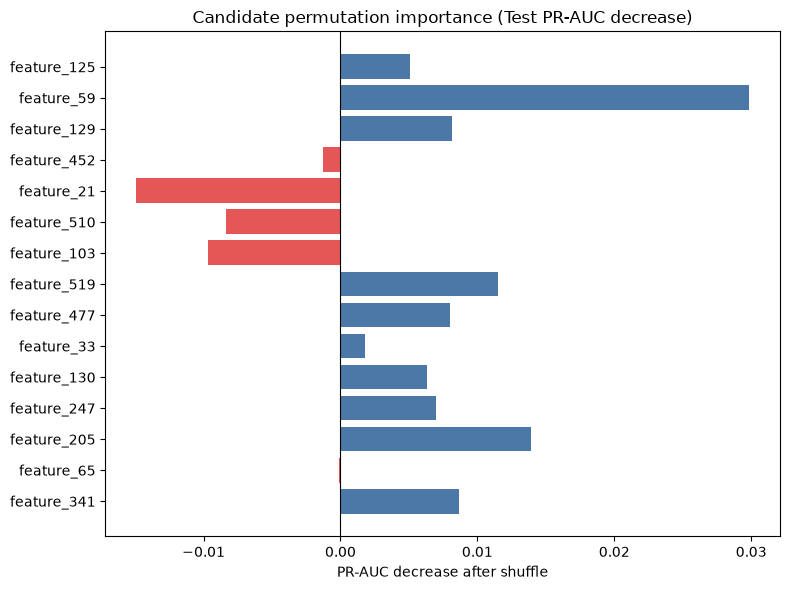

In [5]:
plot_data = evidence.head(15).sort_values('evidence_count')
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4C78A8' if value >= 0 else '#E45756' for value in plot_data['permutation_importance_mean'].fillna(0)]
ax.barh(plot_data['feature'], plot_data['permutation_importance_mean'].fillna(0), color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set(title='Candidate permutation importance (Test PR-AUC decrease)', xlabel='PR-AUC decrease after shuffle')
fig.tight_layout()
fig.savefig(REPORT_DIR / 'candidate_feature_importance.png', dpi=160)
plt.show()

## 4. Monitoring candidate table
Train Pass 분포의 median과 MAD로 강건한 후보 한계를 계산합니다. 운영 데이터 가용성을 고려해 Train 결측률 20% 초과 feature는 모니터링 후보에서 제외합니다. 이는 관리도 한계나 출하 판정 기준이 아니며, 시간순 안정성과 실제 공정 spec을 확인하기 전까지 탐색적 스크리닝 기준으로만 사용합니다.

In [6]:
monitoring = robust_monitoring_candidates(
    evidence, X_train, y_train, minimum_evidence=2, max_features=10, max_missing_rate=0.20
)
monitoring.to_csv(REPORT_DIR / 'monitoring_candidates.csv', index=False)
display(monitoring)

,feature,evidence_count,fail_shift_direction,train_pass_n,train_missing_rate,pass_median,pass_mad,candidate_lower_limit,candidate_upper_limit,limit_method,validation_status
0,feature_59,4,higher,1165,0.003990,0.80180,2.90090,-12.100823,13.704423,Pass median ± 3×robust sigma (MAD),engineering and temporal validation required
1,feature_129,4,higher,1161,0.007183,-0.14190,0.42580,-2.035773,1.751973,Pass median ± 3×robust sigma (MAD),engineering and temporal validation required
2,feature_125,4,lower,1161,0.007183,1.14400,0.17910,0.347399,1.940601,Pass median ± 3×robust sigma (MAD),engineering and temporal validation required
3,feature_205,3,higher,1166,0.003192,7.66000,1.78000,-0.257084,15.577084,Pass median ± 3×robust sigma (MAD),engineering and temporal validation required
4,feature_477,3,higher,1166,0.003192,5.19305,1.21000,-0.188788,10.574888,Pass median ± 3×robust sigma (MAD),engineering and temporal validation required
5,feature_130,3,higher,1161,0.007183,0.75730,0.06430,0.471306,1.043294,Pass median ± 3×robust sigma (MAD),engineering and temporal validation required
6,feature_33,3,higher,1170,0.000000,8.76960,0.22370,7.774627,9.764573,Pass median ± 3×robust sigma (MAD),engineering and temporal validation required
7,feature_452,3,lower,1169,0.000798,5.27650,0.57230,2.731024,7.821976,Pass median ± 3×robust sigma (MAD),engineering and temporal validation required
8,feature_510,3,higher,1168,0.001596,46.31060,13.35480,-13.088879,105.710079,Pass median ± 3×robust sigma (MAD),engineering and temporal validation required
9,feature_103,3,higher,1168,0.001596,-0.01020,0.00175,-0.017984,-0.002416,Pass median ± 3×robust sigma (MAD),engineering and temporal validation required


## Limitations and next validation
- 비식별 feature이므로 장비·공정 step·소재와 연결하기 전에는 물리 원인을 확정할 수 없습니다.
- impurity importance는 연속형 및 상관 feature에 편향될 수 있습니다.
- permutation importance는 Fail 21건인 단일 Test 표본에 민감하며 음수 값도 발생할 수 있습니다.
- 후보 한계는 시간순 drift, 장비별 분포, 실제 spec 및 오경보 비용으로 재검증해야 합니다.